## Step 1: Load Dataset and import necessary libraries

In [16]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/m5-forecasting-accuracy/calendar.csv
/kaggle/input/competitions/m5-forecasting-accuracy/sample_submission.csv
/kaggle/input/competitions/m5-forecasting-accuracy/sell_prices.csv
/kaggle/input/competitions/m5-forecasting-accuracy/sales_train_validation.csv
/kaggle/input/competitions/m5-forecasting-accuracy/sales_train_evaluation.csv


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [18]:
BASE_PATH = ('/kaggle/input/competitions/m5-forecasting-accuracy/')
calendar_path = os.path.join(BASE_PATH, 'calendar.csv')
sell_prices_path = os.path.join(BASE_PATH, 'sell_prices.csv')
sales_train_val_path = os.path.join(BASE_PATH, 'sales_train_validation.csv')
sales_train_eval_path = os.path.join(BASE_PATH, 'sales_train_evaluation.csv')

In [19]:
calendar_df = pd.read_csv(calendar_path)
sell_prices_df = pd.read_csv(sell_prices_path)
sales_train_val_df = pd.read_csv(sales_train_val_path)
sales_train_eval_df = pd.read_csv(sales_train_eval_path)

## Step 2: EDA

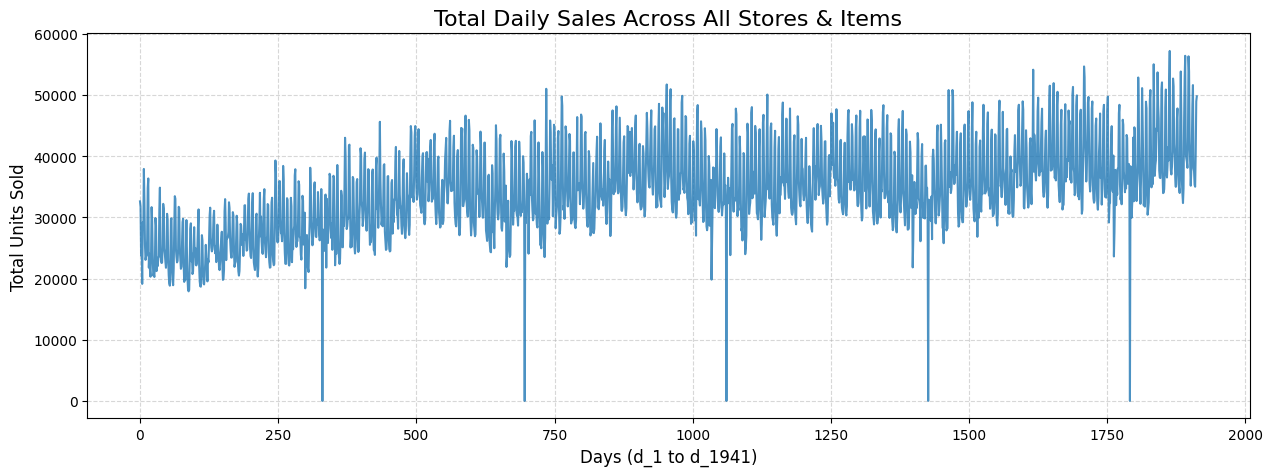

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Extract only the daily sales columns (d_1, d_2, ..., d_1941)
d_cols = [c for c in sales_train_val_df.columns if c.startswith('d_')]

# 2. Sum the sales across all items for each day
total_daily_sales = sales_train_val_df[d_cols].sum(axis=0)

# 3. Plot the total sales
plt.figure(figsize=(15, 5))
plt.plot(total_daily_sales.values, color='tab:blue', alpha=0.8)
plt.title('Total Daily Sales Across All Stores & Items', fontsize=16)
plt.xlabel('Days (d_1 to d_1941)', fontsize=12)
plt.ylabel('Total Units Sold', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

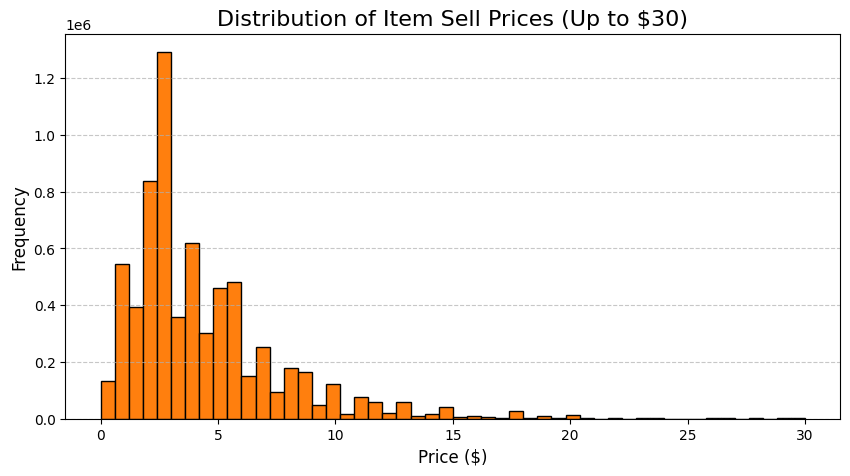

In [21]:
plt.figure(figsize=(10, 5))

# Plotting a histogram of the 'sell_price' column
# We limit the range to 0-30 because there are a few very high-priced outliers
plt.hist(sell_prices_df['sell_price'], bins=50, range=(0, 30), color='tab:orange', edgecolor='black')

plt.title('Distribution of Item Sell Prices (Up to $30)', fontsize=16)
plt.xlabel('Price ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

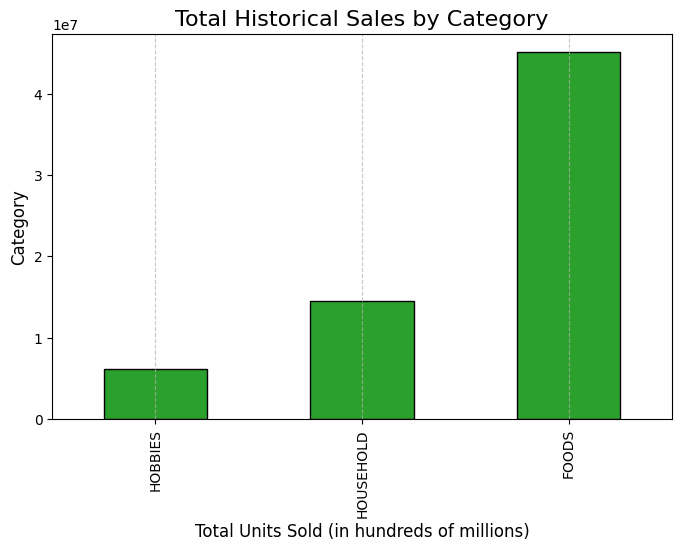

In [22]:
# 1. Sum all daily sales for each item to get a 'Total Sales' column
sales_train_val_df['total_sales'] = sales_train_val_df[d_cols].sum(axis=1)

# 2. Group by category and sum up the total sales
category_sales = sales_train_val_df.groupby('cat_id')['total_sales'].sum().sort_values()

# 3. Plot the bar chart
plt.figure(figsize=(8, 5))
category_sales.plot(kind='bar', color='tab:green', edgecolor='black')
plt.title('Total Historical Sales by Category', fontsize=16)
plt.xlabel('Total Units Sold (in hundreds of millions)', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# Clean up the temporary column to save memory
sales_train_val_df.drop('total_sales', axis=1, inplace=True)

## Step 3: Baseline model

In [23]:
######## predict the last 28 days pattern

# grab last 28 days
last_28_cols = d_cols[-28:]

last_28_days = sales_train_val_df[last_28_cols]

# Calculate the average daily sales for each item (row-wise mean)
last_28_d_mean = last_28_days.mean(axis=1)

# Initialize the submission DataFrame with just the 'id' column
submission = sales_train_val_df[['id']].copy()

# adding the 28 days to the submission df
for i in range(1, 29):
    submission[f'F{i}'] = last_28_d_mean.values

# adding eval data by duplicating and changing id name
eval_sub = submission.copy()
eval_sub['id'] = eval_sub['id'].str.replace('_validation', '_evaluation')

final_submission = pd.concat([submission, eval_sub], ignore_index=True)

# Save the final submission to a CSV file
final_submission.to_csv('submission.csv', index=False)

## Step 4: Feature engineering

In [24]:
id_columns = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']

df_long = pd.melt(
    sales_train_val_df,
    id_vars=id_columns,
    value_vars=d_cols,
    var_name='day',
    value_name='sales'
)

df_long.shape

(58327370, 8)

In [25]:
df_long['sales'] = df_long['sales'].astype('int16')

In [26]:
# lag feature(past values): sales 7/28 days ago
df_long['lag_7'] = df_long.groupby('id')['sales'].shift(7)
df_long['lag_28'] = df_long.groupby('id')['sales'].shift(28)

In [27]:
# rolling feature(moving average): average feature of last 7/28 days
df_long['rolling_mean_7'] = df_long.groupby('id')['sales'].transform(lambda x: x.shift(1).rolling(7).mean())
df_long['rolling_mean_28'] = df_long.groupby('id')['sales'].transform(lambda x: x.shift(1).rolling(28).mean())

In [28]:
df_long[df_long['id'] == 'HOBBIES_1_008_CA_1_validation'].head(35)

,id,item_id,dept_id,cat_id,store_id,state_id,day,sales,lag_7,lag_28,rolling_mean_7,rolling_mean_28
7,HOBBIES_1_008_CA_1_validation,HOBBIES_1_008,HOBBIES_1,HOBBIES,CA_1,CA,d_1,12,NaN,NaN,NaN,NaN
30497,HOBBIES_1_008_CA_1_validation,HOBBIES_1_008,HOBBIES_1,HOBBIES,CA_1,CA,d_2,15,NaN,NaN,NaN,NaN
60987,HOBBIES_1_008_CA_1_validation,HOBBIES_1_008,HOBBIES_1,HOBBIES,CA_1,CA,d_3,0,NaN,NaN,NaN,NaN
91477,HOBBIES_1_008_CA_1_validation,HOBBIES_1_008,HOBBIES_1,HOBBIES,CA_1,CA,d_4,0,NaN,NaN,NaN,NaN
121967,HOBBIES_1_008_CA_1_validation,HOBBIES_1_008,HOBBIES_1,HOBBIES,CA_1,CA,d_5,0,NaN,NaN,NaN,NaN
152457,HOBBIES_1_008_CA_1_validation,HOBBIES_1_008,HOBBIES_1,HOBBIES,CA_1,CA,d_6,4,NaN,NaN,NaN,NaN
182947,HOBBIES_1_008_CA_1_validation,HOBBIES_1_008,HOBBIES_1,HOBBIES,CA_1,CA,d_7,6,NaN,NaN,NaN,NaN
213437,HOBBIES_1_008_CA_1_validation,HOBBIES_1_008,HOBBIES_1,HOBBIES,CA_1,CA,d_8,5,12.0,NaN,5.285714,NaN
243927,HOBBIES_1_008_CA_1_validation,HOBBIES_1_008,HOBBIES_1,HOBBIES,CA_1,CA,d_9,7,15.0,NaN,4.285714,NaN
274417,HOBBIES_1_008_CA_1_validation,HOBBIES_1_008,HOBBIES_1,HOBBIES,CA_1,CA,d_10,0,0.0,NaN,3.142857,NaN


In [29]:
# calendar feature
df_long = df_long.merge(calendar_df, left_on='day', right_on='d', how='left')
df_long.drop(columns=['d'], inplace=True)

In [ ]:
conditions = [
    df_long['state_id'] == 'CA',
    df_long['state_id'] == 'TX',
    df_long['state_id'] == 'WI'
]

# Define which column to grab data from for each condition
choices = [
    df_long['snap_CA'],
    df_long['snap_TX'],
    df_long['snap_WI']
]

# Create the single 'snap' column vectorially
df_long['snap'] = np.select(conditions, choices, default=0)

df_long.drop(columns=['snap_CA', 'snap_TX', 'snap_WI'], inplace=True)

In [33]:
df_long['is_event'] = df_long['event_name_1'].notna().astype('int8') 

In [34]:
# train val split
d_cols = sorted([c for c in sales_train_val_df.columns if c.startswith('d_')], 
                key=lambda x: int(x.split('_')[1]))

train_mask = df_long['day'].isin(d_cols[:-28])
val_mask = df_long['day'].isin(d_cols[-28:])

train_df = df_long[train_mask]
val_df = df_long[val_mask]

In [35]:
print(train_df.shape, val_df.shape)

(57473650, 24) (853720, 24)
